In [1]:
import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fastf1 import plotting
from src.plotset import setup_plot
from src.plotset import save_fig

setup_plot()

Matplotlib rcParams initialized with custom style.


In [2]:
fastf1.Cache.enable_cache('./f1_cache')
fastf1.Cache.get_cache_info()

('./f1_cache', 2219960323)

In [3]:
session = fastf1.get_session(2026, 1, 'R')
session.load()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api          

In [7]:
drivers = session.drivers
drivers = [session.get_driver(drv).Abbreviation for drv in drivers]

In [8]:
comp_palette = {'1_SOFT': '#da291c',
                '2_SOFT': '#da291c',
                '3_SOFT': '#da291c',
                '1_MEDIUM': '#ffd12e',
                '2_MEDIUM': '#ffd12e',
                '3_MEDIUM': '#ffd12e',
                '1_HARD': '#f0f0ec',
                '2_HARD': '#f0f0ec',
                '3_HARD': '#f0f0ec'
}

Matplotlib rcParams initialized with custom style.


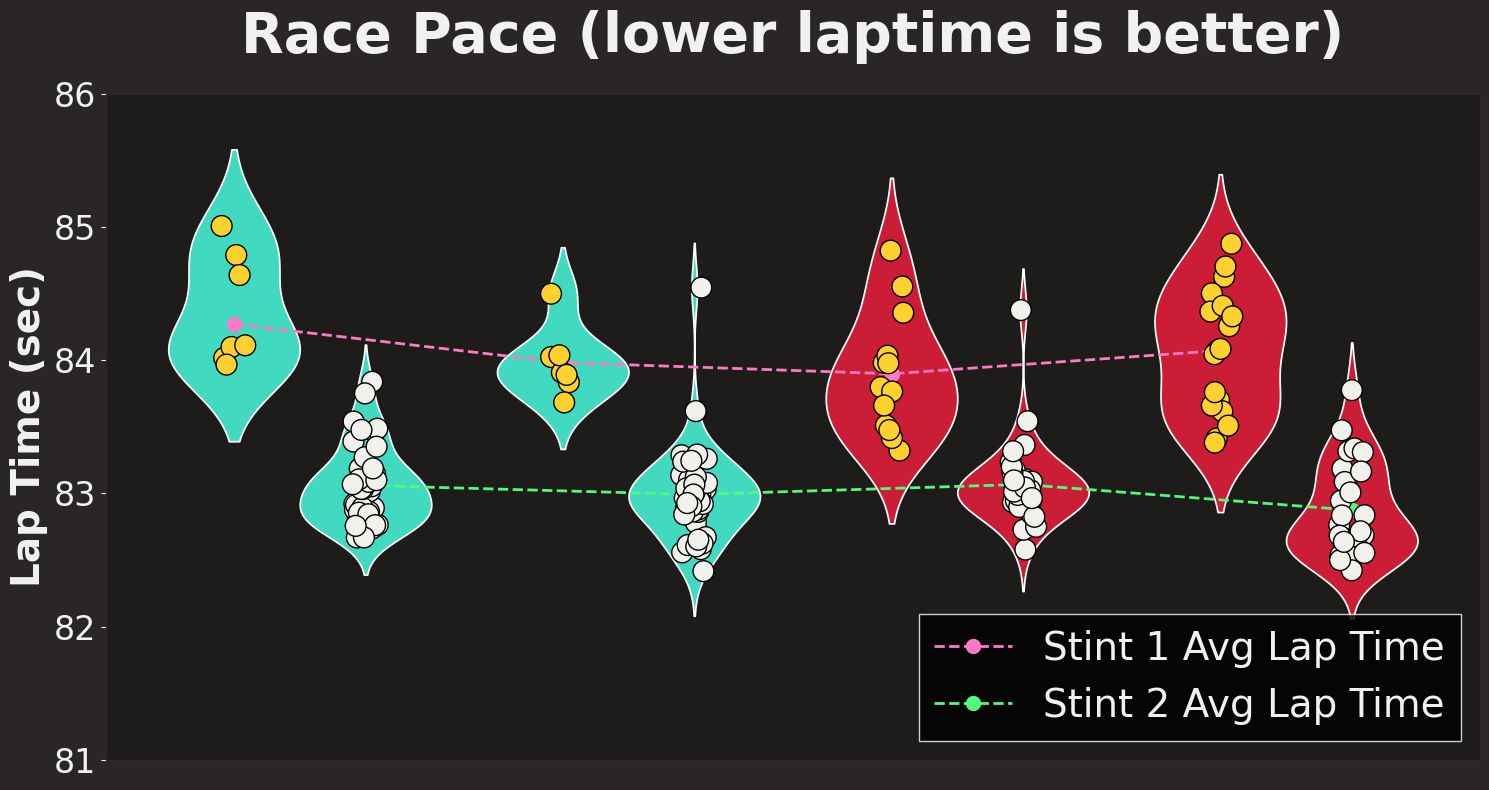

In [44]:
setup_plot(xyticksize=24,axeslabel=28, figtitle=40, legendfont=28)

fig, ax = plt.subplots(figsize=(15,8))

for drv in drivers[:4]:

    df = session.laps.pick_drivers(drv).pick_quicklaps(1.03).copy()
    df['LapTime'] = df['LapTime'].dt.total_seconds()
    df['Stint_Compound'] = df.apply(lambda x: str(int(x['Stint'])) + '_'+ x['Compound'],axis=1)

    color = plotting.get_driver_color(session=session,identifier=drv)

    sns.violinplot(df,x='Driver',y='LapTime',hue='Stint_Compound',palette=[color]*df.Stint.nunique(),
                inner=None,linecolor='w',legend=False)
    sns.stripplot(df,x='Driver',y='LapTime',hue='Stint_Compound',palette=comp_palette
                ,jitter=0.08,linewidth=1,size=15,edgecolor='k',dodge=True,legend=False)

# Collect laps
mean_laps = (
    session.laps.pick_drivers(drivers[:4])
    .pick_quicklaps(1.03)
    .copy()
)
mean_laps['LapTime'] = mean_laps['LapTime'].dt.total_seconds()

# Mean per driver+stint
driver_stint_means = mean_laps.groupby(["Driver", "Stint"])["LapTime"].mean().reset_index()

# Pivot: rows=Driver, cols=Stint
pivot_means = driver_stint_means.pivot(index="Driver", columns="Stint", values="LapTime")
pivot_means = pivot_means.loc[['RUS','ANT','LEC','HAM']]

# Plot one line per stint across drivers
for stint in pivot_means.columns[:1]:
    ax.plot(
        [-0.2,0.8,1.8,2.8],            # x = driver index
        pivot_means[stint].values,          # y = mean laptimes for that stint
        marker="o", linestyle="--", linewidth=2, markersize=10,
        label=f"Stint {int(stint)} Avg Lap Time"
    )

# Plot one line per stint across drivers
for stint in pivot_means.columns[1:]:
    ax.plot(
        [0.2,1.2,2.2,3.2],            # x = driver index
        pivot_means[stint].values,          # y = mean laptimes for that stint
        marker="o", linestyle="--", linewidth=2, markersize=10,
        label=f"Stint {int(stint)} Avg Lap Time"
    )

ax.legend(loc='lower right')
ax.set_ylim(81,86)
ax.set_ylabel("Lap Time (sec)")
ax.set_xlabel("")
ax.set_xticks([])
ax.set_title('Race Pace (lower laptime is better)',pad=30)

ax.grid(visible=False)

In [45]:
save_fig(fig, name='race_pace', loc='Reel24', trs=True)

Figure saved at ./media/Reel24/race_pace.png


In [14]:
rus = session.laps.pick_drivers('RUS').copy()
rus['LapEndTime'] = rus['Time'].dt.total_seconds()
rus = rus.set_index('LapNumber')['LapEndTime']

In [16]:
ant = session.laps.pick_drivers('ANT').copy()
ant['LapEndTime'] = ant['Time'].dt.total_seconds()
ant = ant.set_index('LapNumber')['LapEndTime']

In [17]:
lec = session.laps.pick_drivers('LEC').copy()
lec['LapEndTime'] = lec['Time'].dt.total_seconds()
lec = lec.set_index('LapNumber')['LapEndTime']

In [18]:
ham = session.laps.pick_drivers('HAM').copy()
ham['LapEndTime'] = ham['Time'].dt.total_seconds()
ham = ham.set_index('LapNumber')['LapEndTime']

In [19]:
g_ant = ant - rus
g_lec = lec - rus
g_ham = ham - rus

Matplotlib rcParams initialized with custom style.


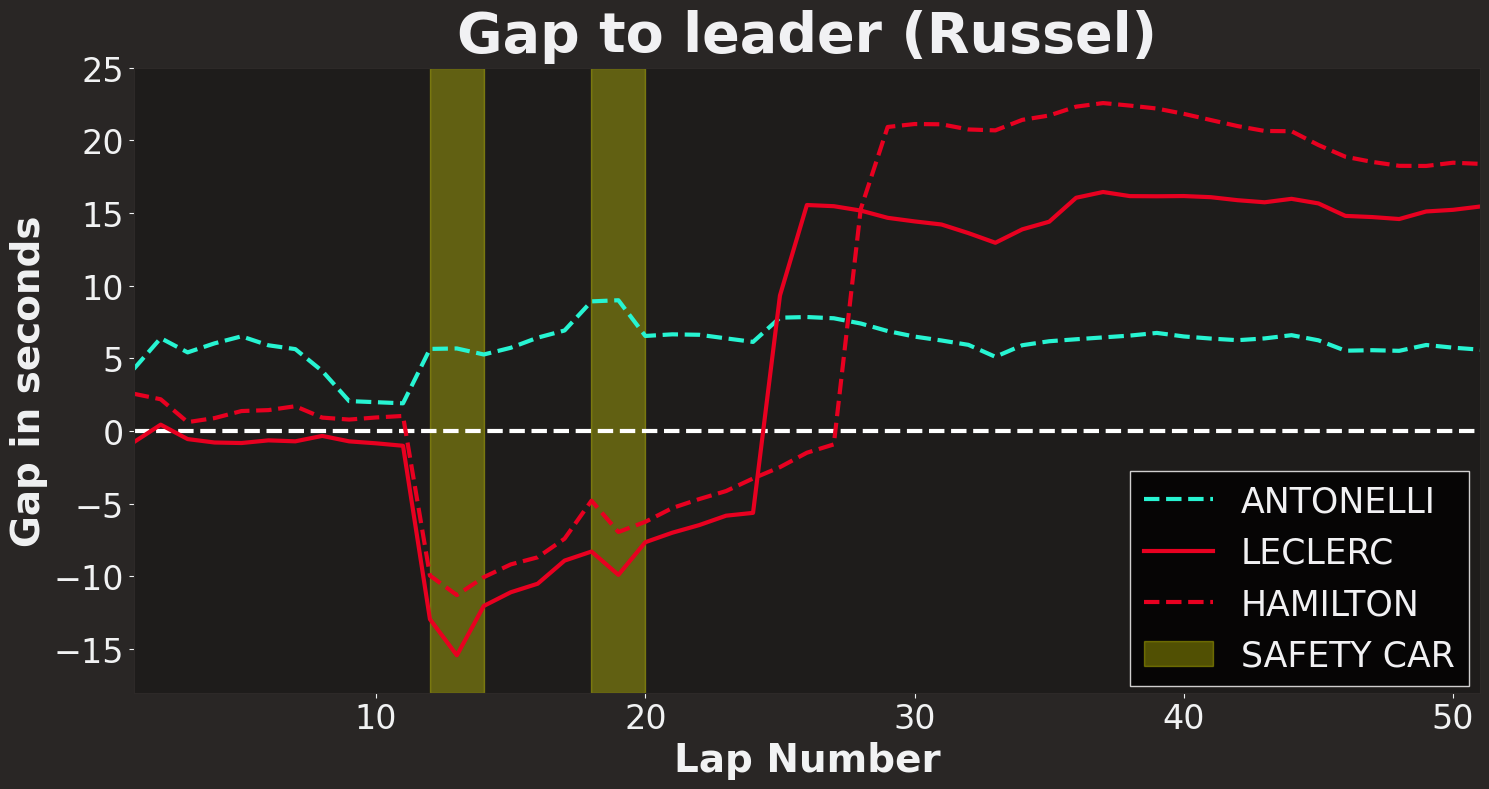

In [57]:
setup_plot(xyticksize=24, axeslabel=28, figtitle=40, legendfont=25)

fig, ax = plt.subplots(figsize = (15,8))

ax.axhline(y=0,color='w',ls='--',lw=3)

ax.plot(g_ant,color=plotting.get_driver_color(identifier='ANT',session=session), ls='--',lw=3,label='ANTONELLI')
ax.plot(g_lec,color=plotting.get_driver_color(identifier='LEC',session=session), ls='-',lw=3,label='LECLERC')
ax.plot(g_ham,color=plotting.get_driver_color(identifier='HAM',session=session), ls='--',lw=3,label='HAMILTON')

ax.fill_between(x=[12,14],y1=-18,y2=25,color='yellow',alpha=0.3,label='SAFETY CAR')
ax.fill_between(x=[18,20],y1=-18,y2=25,color='yellow',alpha=0.3,label=None)

ax.set_xlabel('Lap Number')
ax.set_ylabel('Gap in seconds')
ax.set_title('Gap to leader (Russel)')

ax.set_xlim(1,51)
ax.set_ylim(-18,25)

ax.legend(loc=(0.74,0.01))
ax.grid(visible=False)

In [58]:
save_fig(fig, name='race_trace', loc='Reel24', trs=True)

Figure saved at ./media/Reel24/race_trace.png


In [38]:
vsc = session.laps.pick_drivers('RUS')[['LapNumber', 'TrackStatus']]
vsc = vsc[vsc.TrackStatus != '1']

In [39]:
vsc

,LapNumber,TrackStatus
887,12.0,16
888,13.0,67
889,14.0,71
893,18.0,126
894,19.0,6
895,20.0,671
909,34.0,167
